# Lab 2 — Nowcasting low visibility at Milano Malpensa
### EUROCONTROL AI Lab · Exercise 2 · a proxy for Low-Visibility Procedures (LVP)

When visibility becomes very poor, airports switch to **Low-Visibility Procedures (LVP)**: runway capacity drops, arrival rates are
reduced and ATFM regulations may follow. Knowing a few hours in advance helps the Network Manager, the airport and ATC.

**Question:** *given the current weather report at Malpensa, what is the probability that visibility drops below 1 500 m in the next 3 hours?*

We use **real METAR reports** (the standard hourly aviation weather report) from Malpensa, 2020–2025. Malpensa issues them;
they are exchanged worldwide through the international meteorological networks, and archived by the
[Iowa Environmental Mesonet](https://mesonet.agron.iastate.edu/request/download.phtml) (Iowa State University), where we downloaded them.

> ⚠️ **Our target is a *proxy* for LVP, not LVP itself.**
> - The data contains **weather observations only**: there is no field saying whether LVP were actually in force.
> - Real LVP are declared by the aerodrome under **local procedures**, mainly based on **runway visual range (RVR)** and **cloud ceiling**.
> - We therefore **define our own target** from the reported visibility: *visibility below 1 500 m in at least one of the next three hourly reports*.
> - It behaves like LVP (rare, in winter, at night, long-lasting), but the model predicts **weather risk**, not the decision to declare LVP.

| | |
|---|---|
| ⏱ **Time** | about 2 hours |
| 🎓 **Prerequisites** | Lab 1 is helpful but not required |

**What you will learn**
1. How to look at raw weather data: units, missing values, errors.
2. How to build a target from **future** observations — here a **proxy** for a label that is not recorded.
3. How to handle **rare events**: why "accuracy" misleads, and what *precision*, *recall* and *PR-AUC* tell us instead.
4. How hyperparameters (class weight, model size, dropout, learning rate) and the **alert threshold** change the result.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, restart and run everything again: *Kernel → Restart Kernel and Run All Cells* (JupyterLab) or *Runtime → Restart session and run all* (Colab).
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

>
> 🧑‍💻 **Optional coding challenges** — a few cells invite those who want to **write code** to try a variation of the exercise.
> They are clearly marked, **switched off** (every line starts with `#`, so running them does nothing) and the rest of the notebook does not depend on them: skip them freely.
> To try one, remove the `#` signs (select the lines and press **Ctrl + /**, or **Cmd + /** on a Mac), fill in the `___` blanks and run the cell.
> The solutions are in the `solutions` folder next to this notebook.

> ✅ **SOLUTIONS NOTEBOOK** — identical to the participant notebook, except that the **optional coding challenges** (🧑‍💻) are solved and executed. Search for 🧑‍💻 to jump to them.

> ☁️ **Running in Google Colab?** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dblue-tech/ai-lab/blob/main/lab2_low_visibility/solutions/Lab2_low_visibility_SOLUTIONS.ipynb)  
> Run the next cell **first**: it copies the lab files (data, code, trained models) from GitHub into Colab, so that the rest of the notebook works exactly as on a PC. Wait for *"Colab ready"* (about half a minute).  
> To keep your own copy with your results: *File → Save a copy in Drive*.  
> **On a lab PC** the next cell does nothing: just run it and continue.

In [1]:
# ---- Only for Google Colab: get the lab files. On a lab PC this cell does nothing. ----
import os                                          # os: folders and files
import sys                                         # sys: information about the running Python
import subprocess                                  # subprocess: runs other programs (git, pip)

IN_COLAB = "google.colab" in sys.modules           # True when this notebook runs in Google Colab
if IN_COLAB:                                       # in Colab only:
    if not os.path.exists("/content/ai-lab"):      # if the lab files are not here yet...
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/dblue-tech/ai-lab.git", "/content/ai-lab"], check=True)   # ...copy them from GitHub
    os.chdir("/content/ai-lab/lab2_low_visibility/solutions")# work inside this notebook's folder, as on a PC
    print("Colab ready — working in", os.getcwd())  # confirm
else:                                              # on a lab PC:
    print("Running on this computer: nothing to do")   # the files are already here

Running on this computer: nothing to do


---
## 0 · Setup

In [2]:
from pathlib import Path                          # Path: builds file paths that work on every operating system
import time                                       # time: measures how long training takes
import numpy as np                                # numpy: calculations on arrays of numbers
import pandas as pd                               # pandas: tables of data
import matplotlib.pyplot as plt                   # matplotlib: plots
import seaborn as sns                             # seaborn: extra plot types (heatmaps)
import torch                                      # PyTorch: neural networks
import torch.nn as nn                             # building blocks of neural networks
from torch.utils.data import Dataset, DataLoader  # tools to feed data in batches
from sklearn.metrics import average_precision_score, precision_score, recall_score  # scores for classification
from sklearn.metrics import precision_recall_curve, confusion_matrix               # curves and tables for classification

SEED = 42                                         # fixed seed for random numbers...
np.random.seed(SEED)                              # ...in numpy...
torch.manual_seed(SEED)                           # ...and in PyTorch, so results are reproducible

DATA_DIR = Path("../data")                        # the data folder sits next to this lab's folder
if not DATA_DIR.exists():                         # if not found (e.g. notebook opened from the solutions folder)...
    DATA_DIR = Path("../../data")                 # ...look one folder higher
if not DATA_DIR.exists():                         # if still not found (notebook opened from the main folder)...
    DATA_DIR = Path("data")                       # ...look inside the current folder
print("PyTorch version:", torch.__version__)      # show the PyTorch version

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

PyTorch version: 2.14.0+cu130


---
## 1 · Load the data
The file uses the letter **`M`** for missing values; we tell pandas to treat `M` as "empty".

In [3]:
raw = pd.read_csv(DATA_DIR / "LIMC.csv", na_values="M", low_memory=False)  # read the file; "M" means missing
raw["valid"] = pd.to_datetime(raw["valid"])                                # observation time: text -> real date/time

print("Rows, columns:", raw.shape)                # size of the table
raw.head(3)                                       # show the first 3 rows

Rows, columns: (52394, 30)


,station,valid,tmpf,dwpf,relh,drct,sknt,p01i,alti,mslp,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,LIMC,2020-01-01 00:50:00,28.4,28.4,100.0,360.0,6.0,0.0,30.39,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.19,LIMC 010050Z 36006KT CAVOK M02/M02 Q1029 NOSIG,NaN
1,LIMC,2020-01-01 01:50:00,28.4,28.4,100.0,10.0,7.0,0.0,30.39,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.39,LIMC 010150Z 01007KT CAVOK M02/M02 Q1029 NOSIG,NaN
2,LIMC,2020-01-01 02:50:00,28.4,28.4,100.0,20.0,5.0,0.0,30.39,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.12,LIMC 010250Z 02005KT CAVOK M02/M02 Q1029 NOSIG,NaN


Each row also contains the original **METAR message**, as pilots and controllers read it:

In [4]:
examples = raw["metar"].sample(5, random_state=1)  # pick 5 rows at random (always the same 5, thanks to random_state)
for message in examples:                           # for each of them...
    print(message)                                 # ...print the METAR text

LIMC 180050Z 33009KT CAVOK 08/M03 Q1020 NOSIG
LIMC 011850Z 03003KT CAVOK 14/11 Q1016 NOSIG
LIMC 052250Z 03005KT CAVOK 02/M03 Q1018 NOSIG
LIMC 162250Z 02004KT 9999 -RA BKN015 13/13 Q1004 NOSIG
LIMC 280650Z 09004KT 060V120 9999 SCT070 27/18 Q1015 NOSIG


**The columns we use** (the archive uses **US units** — we convert them below):

| Column | Meaning | Unit in the file |
|---|---|---|
| `valid` | observation time | UTC |
| `tmpf`, `dwpf` | air temperature, dew point | °F |
| `drct`, `sknt` | wind direction, wind speed | degrees, knots |
| `alti` | QNH (pressure) | inches of mercury |
| `vsby` | visibility | **statute miles** |

The *dew point* is the temperature at which the air would be saturated. When temperature and dew point are close, the air is almost saturated — the condition for fog.

---
## 2 · Look at the data before modelling

### 2.1 One report per hour
Malpensa issues a routine report every hour at **HH:50**; a few extra "special" reports appear at other minutes.
We keep only the routine reports and place them on a regular hourly timeline, so that missing hours become visible.

In [5]:
minutes = raw["valid"].dt.minute                        # the minute of each report
print("Reports per minute of the hour:")                # title of the next output
print(minutes.value_counts())                           # how many reports at :50, :20, ...

routine = raw[minutes == 50]                            # keep only the routine reports (minute 50)
routine = routine.drop_duplicates("valid")              # remove any duplicated time
routine = routine.set_index("valid")                    # use the time as the label of each row
routine = routine.sort_index()                          # sort by time
obs = routine.asfreq("h")                               # force one row per hour: missing hours appear as empty rows

print("Hours in the timeline:", len(obs))               # total number of hours from 2020 to 2025
print("Hours without a report:", obs["vsby"].isna().sum())  # how many are missing

Reports per minute of the hour:
valid
50    52298
20       96
Name: count, dtype: int64
Hours in the timeline: 52584
Hours without a report: 294


### 2.2 Convert to aviation units

In [6]:
wx = pd.DataFrame(index=obs.index)                      # a new, empty table with the same hourly timeline

wx["temp_c"] = (obs["tmpf"] - 32) * 5 / 9               # temperature: °F -> °C
wx["dew_c"] = (obs["dwpf"] - 32) * 5 / 9                # dew point: °F -> °C
wx["spread_c"] = wx["temp_c"] - wx["dew_c"]             # temperature minus dew point: 0 means saturated air
wx["rh"] = obs["relh"]                                  # relative humidity, already in %
wx["wind_dir"] = obs["drct"]                            # wind direction in degrees (empty when calm or variable)
wx["wind_kt"] = obs["sknt"]                             # wind speed in knots
wx["vis_m"] = obs["vsby"] * 1609.34                     # visibility: statute miles -> metres
wx["qnh_hpa"] = obs["alti"] * 33.8639                   # pressure: inches of mercury -> hectopascal

impossible = (wx["qnh_hpa"] < 950) | (wx["qnh_hpa"] > 1060)  # a few pressure values are encoding errors...
print("Impossible pressure values removed:", impossible.sum())  # ...show how many...
wx.loc[impossible, "qnh_hpa"] = np.nan                  # ...and replace them with "missing"

wx.describe().round(1)                                  # summary statistics of every column

Impossible pressure values removed: 4


,temp_c,dew_c,spread_c,rh,wind_dir,wind_kt,vis_m,qnh_hpa
count,52286.0,52285.0,52285.0,52285.0,42306.0,52294.0,52290.0,52286.0
mean,14.0,8.2,5.8,72.3,150.1,4.7,9057.0,1016.2
std,8.8,7.5,5.6,21.7,126.8,2.7,2257.1,7.8
min,-7.0,-21.0,0.0,6.8,0.0,0.0,0.0,982.1
25%,7.0,3.0,1.0,55.6,20.0,3.0,9994.0,1011.9
50%,14.0,9.0,4.0,76.8,120.0,4.0,9994.0,1015.9
75%,21.0,15.0,9.0,92.9,250.0,6.0,9994.0,1021.0
max,37.0,24.0,38.0,100.0,360.0,31.0,9994.0,1044.0


📖 **Reading:** the values now look familiar (temperatures −7 to 37 °C, QNH around 1 016 hPa). Wind direction is missing in about 20 % of the hours:
these are **calm or variable** winds (METAR `00000KT` or `VRB02KT`) — information, not an error.

### 2.3 Visibility — how rare is low visibility?

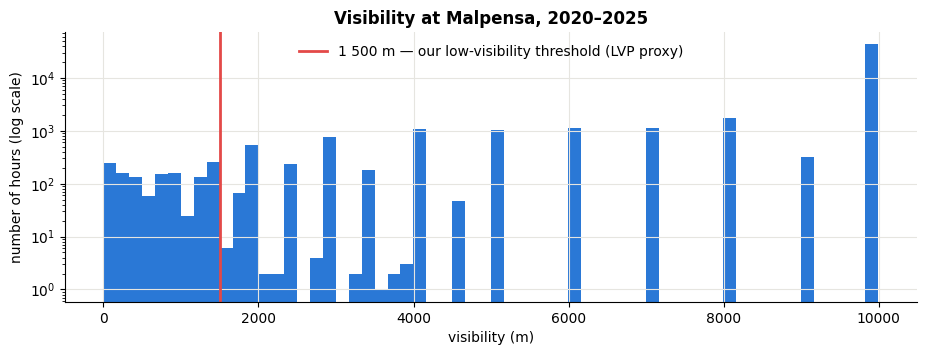

Hours with visibility below 1 500 m: 2.5 %


In [7]:
plt.figure(figsize=(11, 3.5))                                          # new figure
plt.hist(wx["vis_m"].dropna(), bins=60, color=PALETTE[0])              # histogram: how many hours at each visibility
plt.axvline(1500, color=PALETTE[7], linewidth=2, label="1 500 m — our low-visibility threshold (LVP proxy)")  # red line
plt.yscale("log")                                                      # log scale, so that small bars remain visible
plt.xlabel("visibility (m)")                                           # horizontal axis label
plt.ylabel("number of hours (log scale)")                              # vertical axis label
plt.title("Visibility at Malpensa, 2020–2025")                         # title
plt.legend()                                                           # legend
plt.show()                                                             # display

wx["low_vis_now"] = (wx["vis_m"] < 1500).astype(float)                 # 1 if visibility < 1500 m, otherwise 0
wx.loc[wx["vis_m"].isna(), "low_vis_now"] = np.nan                     # keep "missing" where visibility is missing
share = wx["low_vis_now"].mean()                                       # share of hours with low visibility
print("Hours with visibility below 1 500 m:", round(share * 100, 1), "%")  # show it as a percentage

📖 **Reading:** most hours pile up on the right: METAR reports "10 km or more" as `9999`, so visibility is **capped** at about 10 km.
Low visibility is **rare**: about **2.5 % of the hours**.

⚠️ This means that a "model" that **always says *no low visibility*** would be right ~97 % of the time — and completely useless.
We will need better measures than accuracy.

### 2.4 When does low visibility happen?

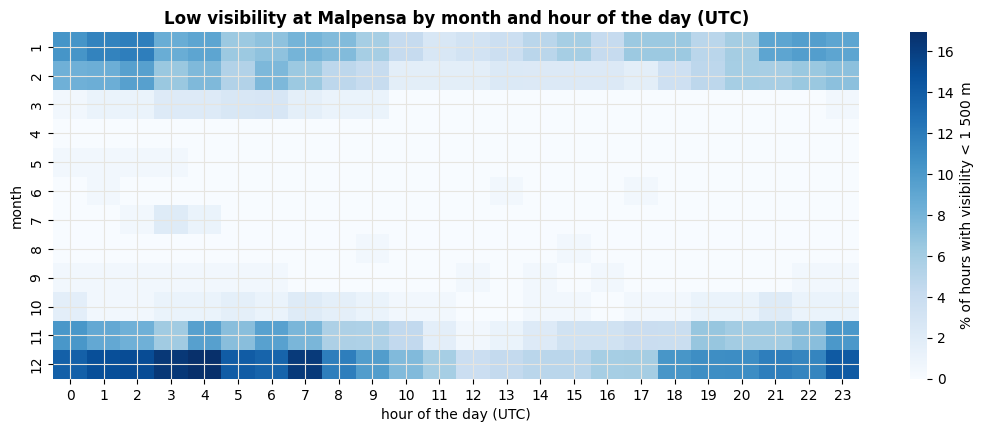

In [8]:
table = pd.DataFrame()                                                 # an empty table
table["month"] = wx.index.month                                        # month of each hour
table["hour"] = wx.index.hour                                          # hour of the day of each hour (UTC)
table["low_vis"] = wx["low_vis_now"].values                            # 1/0 low visibility
percent = table.pivot_table(index="month", columns="hour", values="low_vis", aggfunc="mean") * 100  # % per month and hour

plt.figure(figsize=(13, 4.5))                                          # new figure
sns.heatmap(percent, cmap="Blues", cbar_kws={"label": "% of hours with visibility < 1 500 m"})  # coloured grid
plt.title("Low visibility at Malpensa by month and hour of the day (UTC)")  # title
plt.xlabel("hour of the day (UTC)")                                    # horizontal axis label
plt.ylabel("month")                                                    # vertical axis label
plt.show()                                                             # display

📖 **Reading:** low visibility is a **winter** phenomenon (November–February) that happens mostly **at night and around sunrise**.
So **month** and **hour** will be useful inputs.

### 2.5 One fog event, hour by hour
We look at the foggiest day of 2023 and the hours around it.

### 🧑‍💻 Optional coding challenge A — low visibility and wind speed
*Optional, for those who want to write code — the rest of the notebook does not depend on it.*

**Task:** draw, for each wind speed (0, 1, 2 … 12 knots), the percentage of hours with visibility below 1 500 m.
**Variation:** do the same with the temperature − dew point spread (`wx["spread_c"]`) instead of the wind speed.

Solution: `solutions/Lab2_low_visibility_SOLUTIONS.ipynb`

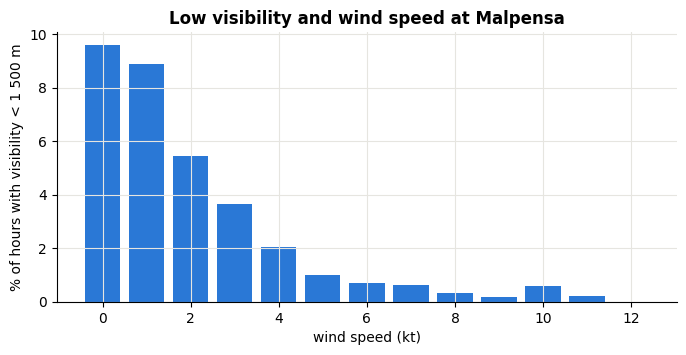

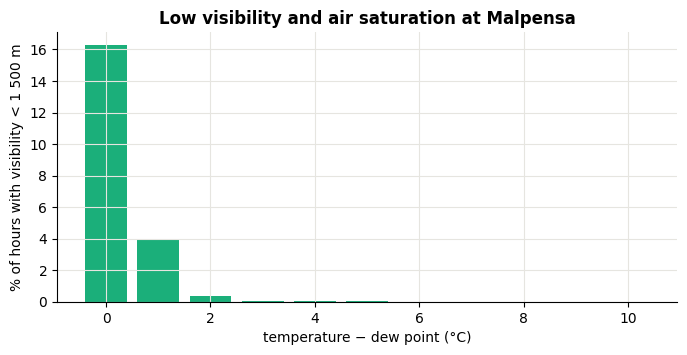

In [9]:
# 🧑‍💻 OPTIONAL CHALLENGE A — SOLUTION
wind_rounded = wx["wind_kt"].round()                         # wind speed rounded to whole knots
share_by_wind = wx["low_vis_now"].groupby(wind_rounded).mean() * 100   # % of low-visibility hours per wind speed
share_by_wind = share_by_wind[share_by_wind.index <= 12]     # keep 0–12 knots (stronger winds are rare)

plt.figure(figsize=(8, 3.5))                                 # new figure
plt.bar(share_by_wind.index, share_by_wind.values, color=PALETTE[0])   # one bar per wind speed
plt.xlabel("wind speed (kt)")                                # horizontal axis label
plt.ylabel("% of hours with visibility < 1 500 m")           # vertical axis label
plt.title("Low visibility and wind speed at Malpensa")       # title
plt.show()                                                   # display

# Variation: the same with the temperature − dew point spread
spread_rounded = wx["spread_c"].round()                      # spread rounded to whole degrees
share_by_spread = wx["low_vis_now"].groupby(spread_rounded).mean() * 100   # % of low-visibility hours per spread
share_by_spread = share_by_spread[(share_by_spread.index >= 0) & (share_by_spread.index <= 10)]   # keep 0–10 °C
plt.figure(figsize=(8, 3.5))                                 # new figure
plt.bar(share_by_spread.index, share_by_spread.values, color=PALETTE[2])   # one bar per spread value
plt.xlabel("temperature − dew point (°C)")                   # horizontal axis label
plt.ylabel("% of hours with visibility < 1 500 m")           # vertical axis label
plt.title("Low visibility and air saturation at Malpensa")   # title
plt.show()                                                   # display
# Reading: low visibility is most frequent with calm or light wind and with saturated air (spread close to 0 °C).

Foggiest day of 2023: 2023-01-01 with 17 hours below 1 500 m


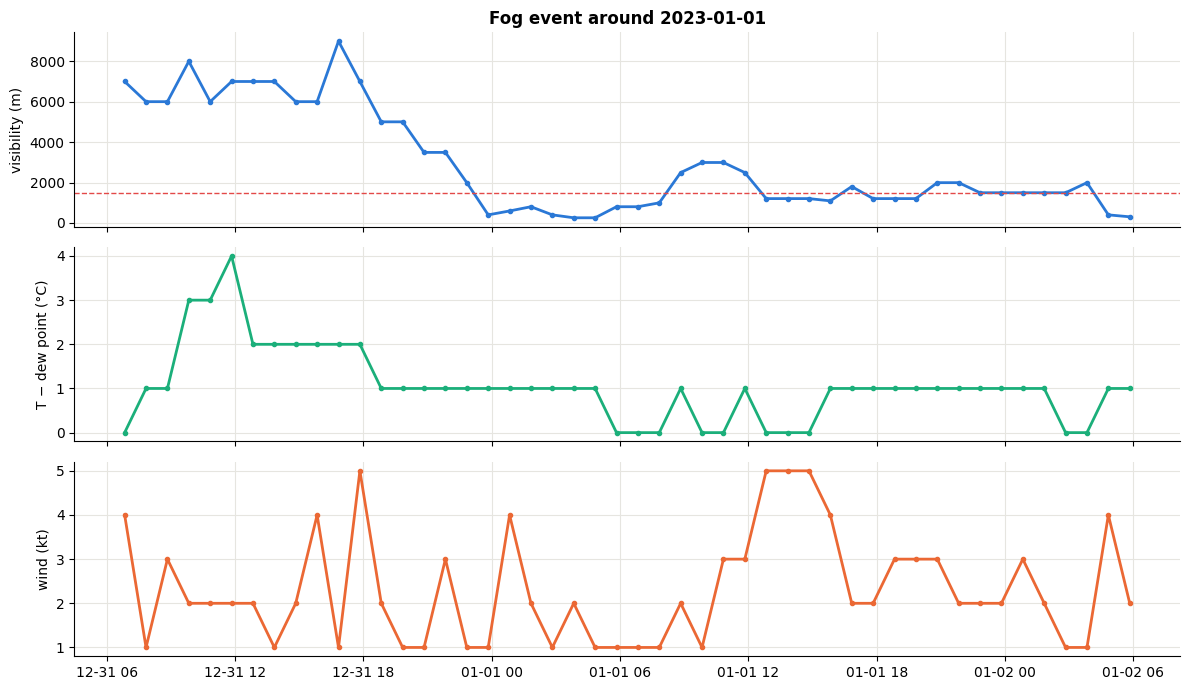

In [10]:
low_vis_2023 = wx.loc["2023", "low_vis_now"]                           # the low-visibility flag, year 2023 only
hours_per_day = low_vis_2023.resample("D").sum()                       # number of low-visibility hours per day
fog_day = hours_per_day.idxmax()                                       # the day with the most low-visibility hours
print("Foggiest day of 2023:", fog_day.date(), "with", int(hours_per_day.max()), "hours below 1 500 m")  # show it

start = fog_day - pd.Timedelta(hours=18)                               # start 18 hours before that day
end = fog_day + pd.Timedelta(hours=30)                                 # end 30 hours after its start
window = wx.loc[start:end]                                             # the rows between start and end

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)           # three plots, one above the other
axes[0].plot(window.index, window["vis_m"], marker="o", markersize=3, color=PALETTE[0])     # visibility
axes[0].axhline(1500, color=PALETTE[7], linestyle="--", linewidth=1)   # the 1 500 m threshold
axes[0].set_ylabel("visibility (m)")                                   # label
axes[0].set_title("Fog event around " + str(fog_day.date()))           # title
axes[1].plot(window.index, window["spread_c"], marker="o", markersize=3, color=PALETTE[2])  # temperature − dew point
axes[1].set_ylabel("T − dew point (°C)")                               # label
axes[2].plot(window.index, window["wind_kt"], marker="o", markersize=3, color=PALETTE[1])   # wind speed
axes[2].set_ylabel("wind (kt)")                                        # label
plt.tight_layout()                                                     # adjust spacing
plt.show()                                                             # display

📖 **Reading:** during the evening visibility falls steadily while temperature and dew point get within 0–1 °C and the wind is almost calm.
Once formed, low visibility **lasts for more than a day**, hovering around the threshold.

### 2.6 Persistence: if visibility is low now, is it still low in the next 3 hours?

In [11]:
future_1h = wx["low_vis_now"].shift(-1)                                # the flag 1 hour later
future_2h = wx["low_vis_now"].shift(-2)                                # the flag 2 hours later
future_3h = wx["low_vis_now"].shift(-3)                                # the flag 3 hours later
next_three = pd.concat([future_1h, future_2h, future_3h], axis=1)      # the three future flags side by side
low_vis_next_3h = next_three.max(axis=1, skipna=False)                 # 1 if ANY of the three is 1 (this will be our target)

now_label = wx["low_vis_now"].map({0: "visibility ≥ 1500 m now", 1: "visibility < 1500 m now"})          # readable labels
future_label = low_vis_next_3h.map({0: "stays ≥ 1500 m for 3 h", 1: "< 1500 m within 3 h"})             # readable labels
persistence_table = pd.crosstab(now_label, future_label, normalize="index") * 100   # % of each case, row by row
persistence_table.round(1)                                             # display, rounded

col_0,< 1500 m within 3 h,stays ≥ 1500 m for 3 h
low_vis_now,,
visibility < 1500 m now,81.7,18.3
visibility ≥ 1500 m now,1.6,98.4


📖 **Reading:** if visibility is low now, it is still low within 3 hours about **80 %** of the time; if it is not low now, it becomes low only
about **1–2 %** of the time. A trivial forecast *"it will stay as it is now"* (**persistence**) is therefore strong — our model must beat it.
The real value is in anticipating when fog **forms** and when it **lifts**.

> **🧭 What the data told us**
> - there is **no LVP field** → our target is a **proxy**: visibility below 1 500 m within 3 hours
> - low visibility is **rare** (~2.5 % of hours) → accuracy is meaningless
> - strong **seasonal and daily** pattern → give month and hour to the model
> - near-saturated air and calm wind are the physical signals; **persistence** is the baseline to beat

---
## 3 · Frame the problem

### 3.1 The question, hour by hour
Imagine we are at Malpensa at a given hour **t** (for example 03:50 UTC). The METAR of 03:50 has just been issued: we know the weather **now**, but not the next reports.
The question the model must answer is:

> *"Given this report, will visibility drop below 1 500 m in **at least one** of the next three reports (04:50, 05:50, 06:50)?"*

```
 time ─────────────────────────────────────────────────────────────────────────────►

           KNOWN at time t                    │         FUTURE (not known at time t)
                                              │
   …     t − 2 h      t − 1 h      [ t ]      │      t + 1 h      t + 2 h      t + 3 h
                                     │        │         │            │            │
                            METAR of time t   │      visibility   visibility   visibility
                                     │        │         └────────────┼────────────┘
                                     ▼        │                      ▼
                        INPUTS: 11 numbers    │        TARGET = 1 if ANY of the three
                        (the weather NOW)     │        is below 1 500 m, otherwise 0
                                     │        │                      │
                                     └──────► model ───► probability that TARGET = 1
```

- The **inputs** come only from the report **at time t** (left of the line).
- The **target** is built from the **next three reports** (right of the line). During training the model is shown the correct target as the answer;
  in real use this future is unknown — that is exactly what we want the model to predict.
- The target is our **proxy for LVP** (see the box at the top of the notebook): it describes the weather, not an LVP declaration.

### 3.2 The 11 inputs at time t

| Input | What it is | From the METAR field |
|---|---|---|
| `temp_c` | air temperature (°C) | `tmpf` |
| `spread_c` | temperature − dew point (°C); 0 = saturated air | `tmpf`, `dwpf` |
| `rh` | relative humidity (%) | `relh` |
| `wind_east`, `wind_north` | wind as two components (kt): east–west and north–south; calm wind = (0, 0) | `drct`, `sknt` |
| `qnh_hpa` | pressure (hPa) | `alti` |
| `vis_m` | **current** visibility (m) | `vsby` |
| `hour_sin`, `hour_cos` | hour of the day on a circle, so that 23:00 is next to 00:00 | `valid` (time) |
| `month_sin`, `month_cos` | month on a circle, so that December is next to January | `valid` (time) |

Unlike Lab 1, the model sees **only the current report** — no past hours. (Adding trends over the previous hours is one of the ideas at the end of the notebook.)

### 3.3 From the timeline to a table of examples
Every hour of 2020–2025 becomes **one example** (one row of the table): 11 inputs measured at that hour, and the target computed from the three following hours.
Then we move one hour forward and build the next example.

```
 row for 03:50:  [ temp, spread, rh, wind_east, wind_north, qnh, vis, hour_sin, hour_cos, month_sin, month_cos ]  →  target (0 or 1)
                   └──────────────────────── measured at 03:50 ──────────────────────────────────────┘      └ from 04:50, 05:50, 06:50
 row for 04:50:  [ … measured at 04:50 … ]                                                                   →  target from 05:50, 06:50, 07:50
 row for 05:50:  [ … measured at 05:50 … ]                                                                   →  target from 06:50, 07:50, 08:50
```

⚠️ **Data leakage.** The target looks into the future; the inputs must **never** do so. If, by mistake, an input contained information from t+1 h
(for example an average of visibility over t−1 h … t+1 h), the model would look excellent in the notebook and fail in real use, where the future is not available.

### 3.4 How the data is split
By **time**, as in Lab 1: train on 2020–2023 · compare settings on 2024 (validation) · final test on 2025.

In [12]:
features = pd.DataFrame(index=wx.index)                                # an empty table on the hourly timeline

features["temp_c"] = wx["temp_c"]                                      # temperature (°C)
features["spread_c"] = wx["spread_c"]                                  # temperature − dew point (°C)
features["rh"] = wx["rh"]                                              # relative humidity (%)

direction = wx["wind_dir"].fillna(0)                                   # wind direction; calm/variable -> 0 (speed is ~0 anyway)
radians = np.deg2rad(direction)                                        # degrees -> radians, needed by sin and cos
features["wind_east"] = np.sin(radians) * wx["wind_kt"]                # east–west component of the wind
features["wind_north"] = np.cos(radians) * wx["wind_kt"]               # north–south component of the wind

features["qnh_hpa"] = wx["qnh_hpa"]                                    # pressure (hPa)
features["vis_m"] = wx["vis_m"]                                        # current visibility (m)

hours = wx.index.hour                                                  # hour of the day, 0–23
features["hour_sin"] = np.sin(2 * np.pi * hours / 24)                  # hour on a circle (sine part)
features["hour_cos"] = np.cos(2 * np.pi * hours / 24)                  # hour on a circle (cosine part)
months = wx.index.month                                                # month, 1–12
features["month_sin"] = np.sin(2 * np.pi * months / 12)                # month on a circle (sine part)
features["month_cos"] = np.cos(2 * np.pi * months / 12)                # month on a circle (cosine part)

FEATURES = list(features.columns)                                      # the list of input names (11 inputs)

# TARGET (proxy for LVP): visibility < 1500 m in any of the next 3 hourly reports.
# The data has no record of LVP being declared — see the box at the top of the notebook.
dataset = features.copy()                                              # copy the inputs...
dataset["target"] = low_vis_next_3h                                    # ...and add the target column
dataset = dataset.dropna()                                             # remove hours with any missing value

print("Usable hours:", len(dataset))                                   # how many complete hours remain
print("Inputs:", FEATURES)                                             # the input names
print("Share of positive hours (target = 1):", round(dataset["target"].mean() * 100, 1), "%")  # how rare the target is

Usable hours: 51599
Inputs: ['temp_c', 'spread_c', 'rh', 'wind_east', 'wind_north', 'qnh_hpa', 'vis_m', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
Share of positive hours (target = 1): 3.6 %


**The target on a real night.** The table below shows the hours before the fog event of §2.5. Look at when the target switches to 1:
it happens **up to three hours before** the visibility actually drops below 1 500 m — because the target looks three reports ahead.
This is precisely what we want to learn to anticipate.

In [13]:
start = fog_day - pd.Timedelta(hours=7)                                # 7 hours before midnight of the fog day
end = fog_day + pd.Timedelta(hours=3)                                  # until 3 hours after midnight
example = pd.DataFrame()                                               # an empty table
example["visibility now (m)"] = wx.loc[start:end, "vis_m"].round(0)    # the visibility of each report
example["below 1500 m now?"] = wx.loc[start:end, "low_vis_now"]        # 1 if below 1500 m at that hour
example["TARGET: below 1500 m in the next 3 h?"] = low_vis_next_3h.loc[start:end]   # the target of each hour
example                                                                # display the table

,visibility now (m),below 1500 m now?,TARGET: below 1500 m in the next 3 h?
valid,,,
2022-12-31 17:50:00,7001.0,0.0,0.0
2022-12-31 18:50:00,5005.0,0.0,0.0
2022-12-31 19:50:00,5005.0,0.0,0.0
2022-12-31 20:50:00,3492.0,0.0,1.0
2022-12-31 21:50:00,3492.0,0.0,1.0
2022-12-31 22:50:00,1996.0,0.0,1.0
2022-12-31 23:50:00,402.0,1.0,1.0
2023-01-01 00:50:00,595.0,1.0,1.0
2023-01-01 01:50:00,805.0,1.0,1.0


In [14]:
is_train = dataset.index < "2024-01-01"                                # True for 2020–2023
is_validation = (dataset.index >= "2024-01-01") & (dataset.index < "2025-01-01")  # True for 2024
is_test = dataset.index >= "2025-01-01"                                # True for 2025

X_all = dataset[FEATURES].values.astype("float32")                     # all inputs as a table of numbers
y_all = dataset["target"].values.astype("float32")                     # all targets as an array of 0/1

print("Training hours  :", is_train.sum(), " positive:", round(y_all[is_train].mean() * 100, 1), "%")          # training
print("Validation hours:", is_validation.sum(), " positive:", round(y_all[is_validation].mean() * 100, 1), "%")  # validation
print("Test hours      :", is_test.sum(), " positive:", round(y_all[is_test].mean() * 100, 1), "%")            # test

Training hours  : 34392  positive: 4.0 %
Validation hours: 8643  positive: 3.3 %
Test hours      : 8564  positive: 2.5 %


### 3.5 How we measure success: precision, recall and PR-AUC

**The model's output.** For each hour the model gives a **probability** (for example 0.72). To raise an alert we compare it with a
**threshold** (for example 0.5): above the threshold → *alert*, below → *no alert*.

**Four possible outcomes.** Every hour then falls into one of four boxes:

|  | reality: low visibility in the next 3 h | reality: no low visibility |
|---|---|---|
| **model: alert** | ✅ **hit** (true positive, *TP*) | ❌ **false alarm** (false positive, *FP*) |
| **model: no alert** | ❌ **miss** (false negative, *FN*) | ✅ **correct quiet hour** (true negative, *TN*) |

From these counts we compute:

| Measure | Question it answers | How it is calculated |
|---|---|---|
| **Precision** | *When we raise an alert, how often is it right?* | hits ÷ all alerts = TP ÷ (TP + FP) |
| **Recall** | *Of all the low-visibility cases, how many did we catch?* | hits ÷ all real cases = TP ÷ (TP + FN) |
| **Accuracy** | *How many hours did we get right, overall?* | (TP + TN) ÷ all hours |

**A worked example.** A year of 8 640 hours contains 290 low-visibility hours. The model raises 400 alerts, and 230 of them are right:
- precision = 230 ÷ 400 = **0.58** → 58 % of the alerts were justified, 42 % were false alarms;
- recall = 230 ÷ 290 = **0.79** → we caught 79 % of the cases and missed 60 hours;
- accuracy = (230 + 8 180) ÷ 8 640 = **97.3 %** — but *"never raise an alert"* would score 96.6 % without catching anything!

👉 With rare events **accuracy is dominated by the many quiet hours** and says almost nothing. Precision and recall look only at the rare cases and the alerts.

**The trade-off.** Lowering the threshold raises more alerts: recall goes up (fewer misses), precision goes down (more false alarms). Raising it does the opposite.
Every threshold gives one (recall, precision) pair; drawing all of them gives the **precision–recall curve** (we will see it in §7.1).

**PR-AUC — one number for all thresholds.** *PR-AUC* means "area under the precision–recall curve". We compute it as the **average precision**:
1. sort the hours from the **highest** to the **lowest** predicted probability;
2. go down the list, as if lowering the threshold one hour at a time;
3. each time we reach a **real** low-visibility hour, write down the precision at that point (hits so far ÷ alerts so far);
4. PR-AUC = the **average** of those precision values.

A tiny example with 6 hours, 3 of them real low-visibility hours:

```
 rank  probability  reality        hits so far  alerts so far   precision noted?
  1       0.95      low vis ✔          1             1          1/1 = 1.00  ← noted
  2       0.80      no                 1             2              –
  3       0.70      low vis ✔          2             3          2/3 = 0.67  ← noted
  4       0.40      low vis ✔          3             4          3/4 = 0.75  ← noted
  5       0.20      no                 3             5              –
  6       0.05      no                 3             6              –

 PR-AUC = (1.00 + 0.67 + 0.75) ÷ 3 = 0.81
```
- If the model ranked **all** the real cases at the top, every noted precision would be 1 → **PR-AUC = 1** (perfect).
- A model that **guesses at random** gets a PR-AUC about equal to the share of real cases: here about **0.03**.
- PR-AUC does not depend on a chosen threshold: it measures how well the model **ranks** risky hours above quiet ones. That is why we use it to compare models,
  and then choose the threshold separately (§8).

In the code these are computed by the `scikit-learn` library: `precision_score`, `recall_score` and `average_precision_score` (PR-AUC).

### 3.6 Baselines to beat
- **"never low visibility"**: always answer 0;
- **persistence**: raise an alert if visibility is below 1 500 m *now*.

In [15]:
def scores(truth, alert, probability=None):                            # computes the measures for one forecast
    result = {}                                                        # empty dictionary for the results
    result["accuracy"] = float(np.mean(truth == alert))                # share of hours answered correctly
    result["precision"] = precision_score(truth, alert, zero_division=0)  # share of alerts that were right
    result["recall"] = recall_score(truth, alert)                      # share of low-visibility cases caught
    if probability is None:                                            # if we only have yes/no answers...
        probability = alert                                            # ...use them as "probabilities"
    result["PR-AUC"] = average_precision_score(truth, probability)     # summary over all thresholds
    return result                                                      # give the results back


truth_validation = y_all[is_validation]                                # true answers on the validation hours
never = np.zeros(len(truth_validation))                                # baseline 1: always 0
persistence_all = (dataset["vis_m"] < 1500).astype(float).values       # baseline 2: 1 if visibility is low now
persistence_validation = persistence_all[is_validation]                # baseline 2 on the validation hours

baseline_table = pd.DataFrame()                                        # an empty table
baseline_table["never low visibility"] = pd.Series(scores(truth_validation, never))              # scores of baseline 1
baseline_table["persistence"] = pd.Series(scores(truth_validation, persistence_validation))      # scores of baseline 2
baseline_table = baseline_table.T.round(3)                             # one row per baseline, rounded
PERSISTENCE_PRAUC = baseline_table.loc["persistence", "PR-AUC"]        # remember persistence's PR-AUC
baseline_table                                                         # display

,accuracy,precision,recall,PR-AUC
never low visibility,0.967,0.000,0.000,0.033
persistence,0.981,0.793,0.544,0.446


📖 **Reading:** *"never low visibility"* has ~97 % accuracy and a **recall of 0** — it misses every single case.
Persistence catches about half of the cases with good precision, but it can **never** anticipate the start of a fog event.

---
## 4 · Prepare the data for PyTorch
Inputs are scaled around 0 using the average and spread of the **training** hours only.

In [16]:
means = X_all[is_train].mean(axis=0)                                   # average of each input, training hours only
spreads = X_all[is_train].std(axis=0)                                  # spread of each input, training hours only
X_scaled = (X_all - means) / spreads                                   # scale every input


class WeatherDataset(Dataset):                                         # a PyTorch Dataset holding our examples
    def __init__(self, X, y):                                          # runs when the dataset is created
        self.X = torch.tensor(X, dtype=torch.float32)                  # inputs as a PyTorch tensor
        self.y = torch.tensor(y, dtype=torch.float32)                  # targets as a PyTorch tensor

    def __len__(self):                                                 # how many examples?
        return len(self.y)                                             # the number of targets

    def __getitem__(self, i):                                          # give example number i
        return self.X[i], self.y[i]                                    # its inputs and its target


train_dataset = WeatherDataset(X_scaled[is_train], y_all[is_train])    # the training examples
print("Training examples:", len(train_dataset))                        # how many

Training examples: 34392


---
## 5 · The neural network
The same kind of small network as in Lab 1, with one addition: **Dropout** randomly switches off some neurons during training — a way to fight overfitting.
The network outputs a score (a *logit*); the **sigmoid** function turns it into a probability between 0 and 1.

In [17]:
class FogMLP(nn.Module):                                               # our neural network
    def __init__(self, n_inputs, hidden=32, dropout=0.0):              # runs when the model is created
        super().__init__()                                             # standard first line of every PyTorch model
        self.layers = nn.Sequential(                                   # a chain of layers:
            nn.Linear(n_inputs, hidden),                               #   layer 1: inputs -> hidden neurons
            nn.ReLU(),                                                 #   non-linearity
            nn.Dropout(dropout),                                       #   randomly switch off a share of neurons (training only)
            nn.Linear(hidden, hidden),                                 #   layer 2: hidden -> hidden
            nn.ReLU(),                                                 #   non-linearity
            nn.Dropout(dropout),                                       #   dropout again
            nn.Linear(hidden, 1),                                      #   output: one score per example
        )                                                              # end of the chain

    def forward(self, x):                                              # what the model does with a batch x
        scores = self.layers(x)                                        # pass the inputs through the layers
        scores = scores.squeeze(1)                                     # shape (batch, 1) -> (batch,)
        return scores                                                  # raw scores ("logits"), not yet probabilities


model = FogMLP(n_inputs=len(FEATURES))                                 # create a model with 11 inputs
print(model)                                                           # show its structure

FogMLP(
  (layers): Sequential(
    (0): Linear(in_features=11, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


---
## 6 · Training
The loss for yes/no questions is the **binary cross-entropy**. Its option **`pos_weight`** says how much more a **missed** low-visibility hour
should cost than a **false alarm**: with `pos_weight = 10`, missing one case costs as much as ten false alarms.

In [18]:
def train_one_epoch(model, loader, loss_function, optimizer):          # one pass over all training batches
    model.train()                                                      # "training mode" (dropout is active)
    for inputs, targets in loader:                                     # take the batches one by one
        optimizer.zero_grad()                                          # 1. reset the previous corrections
        scores = model(inputs)                                         # 2. forward pass
        loss = loss_function(scores, targets)                          # 3. how wrong are we?
        loss.backward()                                                # 4. compute the corrections
        optimizer.step()                                               # 5. apply the corrections


def predict_probability(model, X):                                     # probabilities for a table of inputs
    model.eval()                                                       # "evaluation mode" (dropout switched off)
    with torch.no_grad():                                              # no corrections needed (faster)
        scores = model(torch.tensor(X))                                # raw scores
        probabilities = torch.sigmoid(scores)                          # scores -> probabilities between 0 and 1
    return probabilities.numpy()                                       # give them back as a numpy array


def train_model(hidden=32, dropout=0.0, learning_rate=0.001, epochs=15, batch_size=256, pos_weight=1.0,
                show_progress=False):                                  # the values after "=" are the defaults
    torch.manual_seed(SEED)                                            # same random start for every run

    model = FogMLP(len(FEATURES), hidden, dropout)                     # a new, untrained model
    loss_function = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))  # binary cross-entropy with class weight
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # the optimizer that applies corrections
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)    # training batches, shuffled

    X_validation = torch.tensor(X_scaled[is_validation])               # validation inputs, as a tensor
    y_validation = torch.tensor(y_all[is_validation])                  # validation targets, as a tensor

    train_losses = []                                                  # training loss after each epoch
    validation_losses = []                                             # validation loss after each epoch
    validation_praucs = []                                             # validation PR-AUC after each epoch
    start_time = time.time()                                           # remember the start time

    for epoch in range(epochs):                                        # repeat for each epoch
        train_one_epoch(model, loader, loss_function, optimizer)       # one pass over the training data

        model.eval()                                                   # evaluation mode
        with torch.no_grad():                                          # no corrections needed
            train_scores = model(torch.tensor(X_scaled[is_train]))     # scores on all training hours
            train_losses.append(loss_function(train_scores, torch.tensor(y_all[is_train])).item())  # training loss
            validation_scores = model(X_validation)                    # scores on the validation hours
            validation_losses.append(loss_function(validation_scores, y_validation).item())        # validation loss
        validation_probabilities = torch.sigmoid(validation_scores).numpy()                         # probabilities
        validation_praucs.append(average_precision_score(y_all[is_validation], validation_probabilities))  # PR-AUC

        if show_progress:                                              # if asked, print one line per epoch
            print("epoch", epoch, "  validation loss", round(validation_losses[-1], 4),
                  "  validation PR-AUC", round(validation_praucs[-1], 3))   # [-1] = the last value

    probabilities = predict_probability(model, X_scaled[is_validation])     # final probabilities on validation
    alerts_at_half = (probabilities >= 0.5).astype(float)              # alerts with the default threshold 0.5

    result = {}                                                        # dictionary for the results
    result["model"] = model                                            # the trained model
    result["train_losses"] = train_losses                              # training loss curve
    result["validation_losses"] = validation_losses                    # validation loss curve
    result["validation_praucs"] = validation_praucs                    # validation PR-AUC curve
    result["validation_probabilities"] = probabilities                 # final validation probabilities
    result["validation_scores"] = scores(y_all[is_validation], alerts_at_half, probabilities)  # final measures
    result["seconds"] = time.time() - start_time                       # training time
    result["settings"] = {"hidden": hidden, "dropout": dropout, "learning_rate": learning_rate, "epochs": epochs,
                          "batch_size": batch_size, "pos_weight": pos_weight}   # the settings used
    return result                                                      # give the results back


def plot_curves(results, labels, title):                               # draws loss and PR-AUC curves of several runs
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))                  # two plots side by side
    for i in range(len(results)):                                      # for each run...
        r = results[i]                                                 # ...take run number i...
        colour = PALETTE[i]                                            # ...and give it a colour
        axes[0].plot(r["train_losses"], color=colour, linestyle="--", linewidth=1.5,
                     label=labels[i] + " — TRAINING (dashed)")                         # training loss: dashed
        axes[0].plot(r["validation_losses"], color=colour, linestyle="-", linewidth=2.5,
                     label=labels[i] + " — VALIDATION (solid)")                        # validation loss: thick solid
        final = str(round(r["validation_praucs"][-1], 3))                               # final PR-AUC as text
        axes[1].plot(r["validation_praucs"], color=colour, label=labels[i] + " (final " + final + ")")  # PR-AUC curve
    axes[1].axhline(PERSISTENCE_PRAUC, color="black", linestyle=":", linewidth=2,
                    label="BASELINE persistence (" + str(PERSISTENCE_PRAUC) + ")")      # baseline: black dotted
    axes[0].set_title("Loss — dashed = training, solid = validation")  # left title
    axes[0].set_xlabel("epoch")                                        # left axis label
    axes[0].legend(fontsize=8)                                         # left legend
    axes[1].set_title("Validation PR-AUC (higher is better)")          # right title
    axes[1].set_xlabel("epoch")                                        # right axis label
    axes[1].legend(fontsize=8)                                         # right legend
    fig.suptitle(title, fontweight="bold")                             # overall title
    plt.tight_layout()                                                 # adjust spacing
    plt.show()                                                         # display

### 6.0 · Watching the training loop at work
The training loop repeats the five steps for every batch: about 135 batches per epoch × 15 epochs, so **about 2 000 times**.
To **see** that at every step the model really receives inputs, gives answers and is compared with the truth, we run the **same five steps** once more,
with a few `print` instructions added.

> 🔍 **Only for studying — we print just a few of the steps.** Printing every step would give about 2 000 tables. We show only
> **the first batch of epochs 1, 2 and 15**, and only **a few of its 256 hours**: the first 4, plus up to 2 hours that were followed by low visibility
> (they are rare, so a batch has only a handful of them). Apart from the printing, the five steps are exactly those of `train_one_epoch`,
> and all the other batches and epochs run normally, without printing.
> This demonstration trains its own copy of the network (`watch_model`): nothing later in the notebook depends on it.

In [19]:
def show_batch(epoch_number, batch_number, number_of_batches, inputs, scores, targets, loss):   # prints one batch
    """Print what the model received, what it answered and the truth, for a few hours of one batch."""
    truth = targets.numpy()                                      # the truth of every hour of the batch (1 = low visibility in 3 h)
    rows = [0, 1, 2, 3]                                          # the first 4 hours of the batch...
    for i in range(len(truth)):                                  # ...plus the first 2 hours followed by low visibility
        if truth[i] == 1 and i not in rows and len(rows) < 6:    # (if the batch has any)
            rows.append(i)                                       # remember this hour
    X = inputs.numpy()[rows] * spreads + means             # the inputs of these hours, back in real units
    table = pd.DataFrame(X.astype(float).round(2), columns=FEATURES)   # one column per input
    table.index = range(1, len(rows) + 1)                        # number the rows 1, 2, 3, ...
    probabilities = torch.sigmoid(scores).detach().numpy()       # the model's answers, as probabilities
    table["→ ANSWER (probability)"] = probabilities[rows].astype(float).round(3)   # what the model answered
    table["TRUTH (1 = low vis. in 3 h)"] = truth[rows].astype(int)   # what really happened
    print("EPOCH", epoch_number, "· batch", batch_number, "of", number_of_batches,
          "· loss of this batch:", round(loss.item(), 4),
          "· hours followed by low visibility in this batch:", int(truth.sum()), "of", len(truth))   # one summary line
    display(table)                                               # show the table under the cell


def train_one_epoch_and_show(model, loader, loss_function, optimizer, epoch_number, batches_to_show=1):   # loop + printout
    """Exactly the five training steps, plus a printout of the first batch(es)."""
    model.train()                                                # training mode
    batch_number = 0                                             # counts the batches of this epoch
    for inputs, targets in loader:                               # take the batches one by one
        batch_number = batch_number + 1                          # this is the next batch
        optimizer.zero_grad()                                    # 1. reset the previous corrections
        scores = model(inputs)                                   # 2. forward pass
        loss = loss_function(scores, targets)                    # 3. how wrong are we?
        if batch_number <= batches_to_show:                      # ONLY FOR STUDYING: for the first batch(es)...
            show_batch(epoch_number, batch_number, len(loader), inputs, scores, targets, loss)   # ...print them
        loss.backward()                                          # 4. compute the corrections
        optimizer.step()                                         # 5. apply them

In [20]:
torch.manual_seed(SEED)                                          # fixed random start, as in train_model
watch_model = FogMLP(len(FEATURES))                                       # a new, untrained network, only for this demonstration
watch_loss_function = nn.BCEWithLogitsLoss()                     # the same loss as in train_model (pos_weight = 1)
watch_optimizer = torch.optim.Adam(watch_model.parameters(), lr=0.001)   # the same optimizer and learning rate
watch_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)                                     # the same training batches as in train_model

EPOCHS_TO_SHOW = [1, 2, 15]                                      # the only epochs we print (studying only)
for epoch_number in range(1, 16):                                # 15 epochs, as in train_model
    if epoch_number in EPOCHS_TO_SHOW:                           # for the chosen epochs...
        train_one_epoch_and_show(watch_model, watch_loader, watch_loss_function, watch_optimizer, epoch_number)   # ...loop + printout
    else:                                                        # for all the other epochs...
        train_one_epoch(watch_model, watch_loader, watch_loss_function, watch_optimizer)   # ...the normal loop, no printing

EPOCH 1 · batch 1 of 135 · loss of this batch: 0.7033 · hours followed by low visibility in this batch: 7 of 256


,temp_c,spread_c,rh,wind_east,wind_north,qnh_hpa,vis_m,hour_sin,hour_cos,month_sin,month_cos,→ ANSWER (probability),TRUTH (1 = low vis. in 3 h)
1,25.0,14.0,41.42,2.82,1.03,1013.89,9994.00,-0.71,-0.71,-0.5,-0.87,0.523,0
2,30.0,19.0,30.90,-5.64,-2.05,1003.05,9994.00,0.00,-1.00,-1.0,0.00,0.490,0
3,28.0,19.0,30.35,-1.71,-4.70,1013.89,9994.00,-0.50,-0.87,0.0,-1.00,0.528,0
4,23.0,6.0,68.94,0.87,4.92,1024.04,9994.00,0.97,-0.26,-1.0,0.00,0.489,0
5,1.0,0.0,100.00,0.00,1.00,1026.08,96.56,-0.50,-0.87,0.5,0.87,0.460,1
6,4.0,4.0,75.16,-0.87,-4.92,1023.03,5005.05,0.00,-1.00,0.5,0.87,0.496,1


EPOCH 2 · batch 1 of 135 · loss of this batch: 0.1226 · hours followed by low visibility in this batch: 11 of 256


,temp_c,spread_c,rh,wind_east,wind_north,qnh_hpa,vis_m,hour_sin,hour_cos,month_sin,month_cos,→ ANSWER (probability),TRUTH (1 = low vis. in 3 h)
1,7.0,7.0,61.03,-7.52,-2.74,1019.98,9994.00,-0.87,-0.50,0.87,0.50,0.013,0
2,12.0,2.0,87.56,1.50,2.60,1022.01,9994.00,-1.00,0.00,-0.87,0.50,0.034,0
3,26.0,10.0,54.05,-3.86,-4.60,1012.87,9994.00,-0.50,0.87,-0.87,-0.50,0.006,0
4,22.0,2.0,88.43,1.71,4.70,1013.89,9994.00,-0.87,0.50,-0.87,-0.50,0.014,0
5,14.0,4.0,76.82,1.37,-3.76,1024.04,9994.00,0.00,-1.00,-0.50,0.87,0.055,1
6,3.0,1.0,93.14,-0.35,-1.97,1002.03,2993.37,0.00,1.00,0.00,1.00,0.323,1


EPOCH 15 · batch 1 of 135 · loss of this batch: 0.0522 · hours followed by low visibility in this batch: 13 of 256


,temp_c,spread_c,rh,wind_east,wind_north,qnh_hpa,vis_m,hour_sin,hour_cos,month_sin,month_cos,→ ANSWER (probability),TRUTH (1 = low vis. in 3 h)
1,17.0,8.0,59.26,4.79,13.16,1010.16,9994.00,0.97,-0.26,-1.00,0.00,0.000,0
2,13.0,1.0,93.65,1.03,2.82,1018.96,9994.00,0.26,0.97,0.50,-0.87,0.001,0
3,19.0,1.0,93.92,0.00,-4.00,1017.95,7000.63,-0.50,0.87,-1.00,0.00,0.033,0
4,6.0,1.0,93.30,1.03,2.82,1017.95,9994.00,1.00,0.00,0.87,-0.50,0.000,0
5,1.0,0.0,100.00,-6.06,-3.50,1002.03,144.84,0.00,1.00,0.00,1.00,0.902,1
6,4.0,2.0,86.79,-1.93,-2.30,1028.11,4007.26,-0.97,-0.26,0.50,0.87,0.304,1


📖 **Reading:** each table is **one step of the loop, frozen for a moment**: on the left the inputs the model received (shown back in real units: °C, %, hPa, metres…), then its **answer** — the probability of low visibility in 3 hours — and the **truth** (1 = it happened). The loss printed above the table is computed from the answers and truths of all 256 hours of the batch; right after the table, steps 4 and 5 use it to correct the weights.
- **Epoch 1:** the network is untrained, so it answers **about 0.5 for every hour**, whatever the inputs: a sunny 30 °C afternoon and an hour already in thick fog (97 m) get almost the same answer.
- **Epoch 2:** the answers have collapsed towards **0** for the ordinary hours (most hours have no low visibility); only the hour with 2 990 m visibility and 93 % humidity gets a higher probability (0.32).
- **Epoch 15:** clear hours are at **0.00**, the hour already in fog gets **0.90**, but the hour with 4 000 m visibility that is followed by low visibility only gets 0.30 — a fog **onset** is the hard case.

The batches are shuffled, so each table shows different hours. Remember that this is **only a window for studying**: in the real training (`train_model`) nothing is printed, but every one of the ~2 000 steps does exactly this.

### 6.1 First training run

epoch 0   validation loss 0.0962   validation PR-AUC 0.532


epoch 1   validation loss 0.0726   validation PR-AUC 0.668


epoch 2   validation loss 0.0714   validation PR-AUC 0.666


epoch 3   validation loss 0.0704   validation PR-AUC 0.664


epoch 4   validation loss 0.0705   validation PR-AUC 0.658


...

epoch 10   validation loss 0.0672   validation PR-AUC 0.677


epoch 11   validation loss 0.0672   validation PR-AUC 0.678


epoch 12   validation loss 0.0671   validation PR-AUC 0.681


epoch 13   validation loss 0.0668   validation PR-AUC 0.687


epoch 14   validation loss 0.0674   validation PR-AUC 0.684
Training time: 3.4 seconds


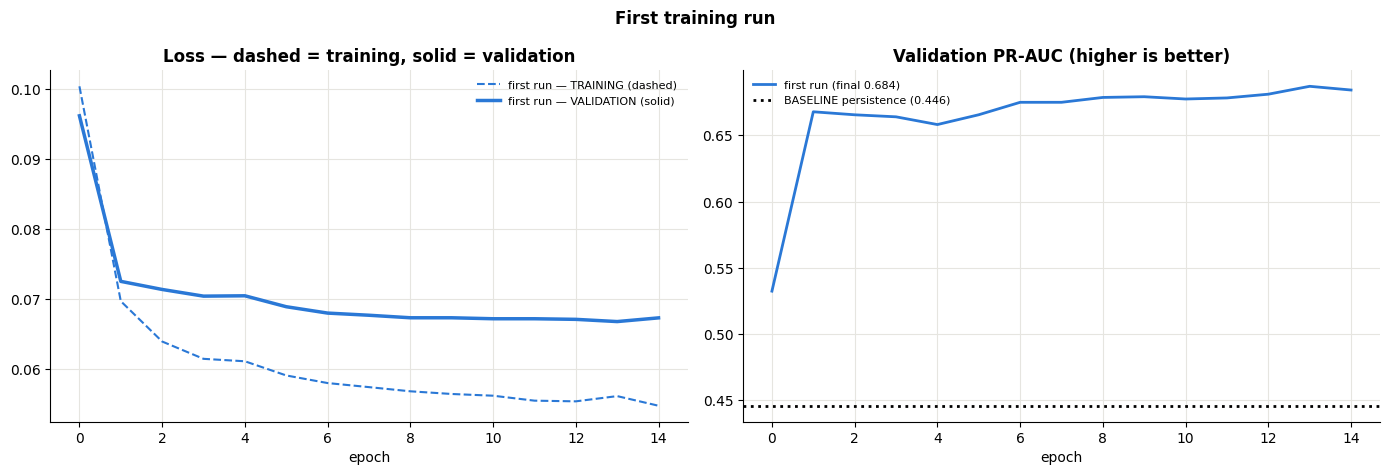

,accuracy,precision,recall,PR-AUC
persistence,0.981,0.793,0.544,0.446
neural network (threshold 0.5),0.978,0.698,0.584,0.684


In [21]:
first_run = train_model(show_progress=True)                            # train with the default settings
print("Training time:", round(first_run["seconds"], 1), "seconds")     # how long it took

plot_curves([first_run], ["first run"], "First training run")          # draw the curves

comparison = pd.DataFrame()                                            # a small comparison table
comparison["persistence"] = baseline_table.loc["persistence"]          # persistence scores
comparison["neural network (threshold 0.5)"] = pd.Series(first_run["validation_scores"])  # model scores
comparison.T.round(3)                                                  # display, one row per method

📖 **Reading:** after a few epochs the network's PR-AUC is clearly **above persistence**: it ranks the risky hours better.
With the default alert threshold of 0.5, its precision and recall are close to persistence — we will choose a better threshold in §8.

---
## 7 · Hyperparameters

### 7.1 Class weight (`pos_weight`) — how much does a missed low-visibility hour cost?

In [22]:
weights = [1.0, 10.0, 30.0]                                            # three class weights to compare
weight_results = []                                                    # empty list for the results
for w in weights:                                                      # for each weight...
    result = train_model(pos_weight=w)                                 # ...train a model...
    weight_results.append(result)                                      # ...and keep its results

weight_labels = ["pos_weight 1", "pos_weight 10", "pos_weight 30"]     # names for the table and the legend
rows = []                                                              # one row per run
for result in weight_results:                                          # for each run...
    rows.append(result["validation_scores"])                           # ...take its validation measures
pd.DataFrame(rows, index=weight_labels).round(3)                       # display them as a table

,accuracy,precision,recall,PR-AUC
pos_weight 1,0.978,0.698,0.584,0.684
pos_weight 10,0.950,0.371,0.797,0.689
pos_weight 30,0.918,0.262,0.843,0.670


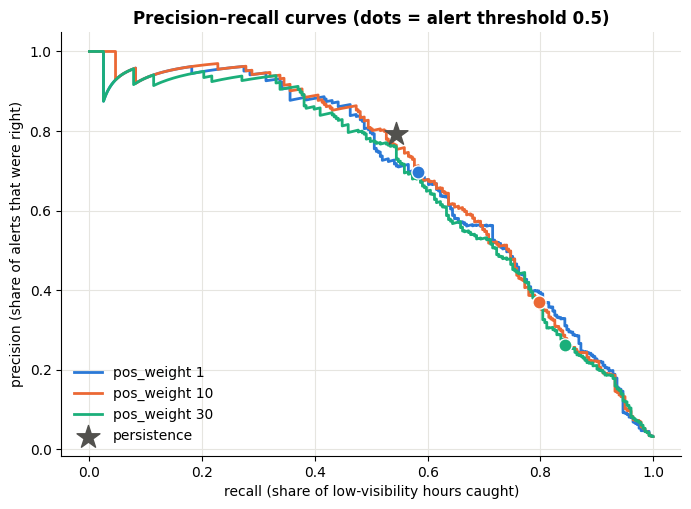

In [23]:
plt.figure(figsize=(8, 5.5))                                           # new figure
truth_validation = y_all[is_validation]                                # true answers on validation hours
for i in range(len(weight_results)):                                   # for each run...
    r = weight_results[i]                                              # ...take run number i
    precision, recall, thresholds = precision_recall_curve(truth_validation, r["validation_probabilities"])  # its curve
    plt.plot(recall, precision, color=PALETTE[i], label=weight_labels[i])                       # draw the curve
    s = r["validation_scores"]                                         # its measures at threshold 0.5
    plt.scatter(s["recall"], s["precision"], color=PALETTE[i], s=90, edgecolor="white", zorder=3)  # dot at threshold 0.5
p = baseline_table.loc["persistence"]                                  # persistence measures
plt.scatter(p["recall"], p["precision"], marker="*", s=300, color="#52514e", label="persistence", zorder=4)  # a star
plt.xlabel("recall (share of low-visibility hours caught)")            # horizontal axis label
plt.ylabel("precision (share of alerts that were right)")              # vertical axis label
plt.title("Precision–recall curves (dots = alert threshold 0.5)")      # title
plt.legend(loc="lower left")                                           # legend
plt.show()                                                             # display

📖 **Reading:** the three **curves almost overlap** — the three models rank the hours in a similar way (similar PR-AUC).
What changes is **where the 0.5 threshold falls** (the dots): a larger `pos_weight` catches more cases (higher recall) but raises more false alarms (lower precision).
Choosing between missed events and false alarms is an **operational decision**, not a mathematical one.

### 7.2 Model size and dropout — overfitting

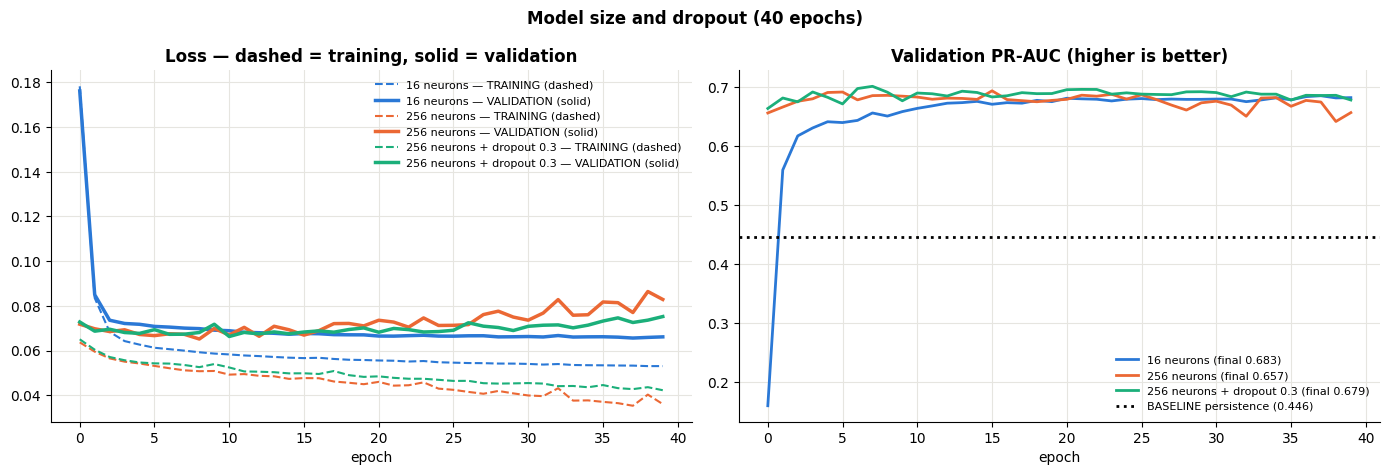

In [24]:
small = train_model(hidden=16, epochs=40)                              # small model, 40 epochs
big = train_model(hidden=256, epochs=40)                               # big model, 40 epochs
big_dropout = train_model(hidden=256, epochs=40, dropout=0.3)          # big model with 30 % dropout
size_results = [small, big, big_dropout]                               # the three runs
plot_curves(size_results, ["16 neurons", "256 neurons", "256 neurons + dropout 0.3"], "Model size and dropout (40 epochs)")  # draw

📖 **Reading:** the big model keeps lowering its **training** loss, but after ~20 epochs its **validation** loss goes up and its PR-AUC becomes
unstable: **overfitting**. With dropout the big model behaves well again.

### 7.3 Learning rate

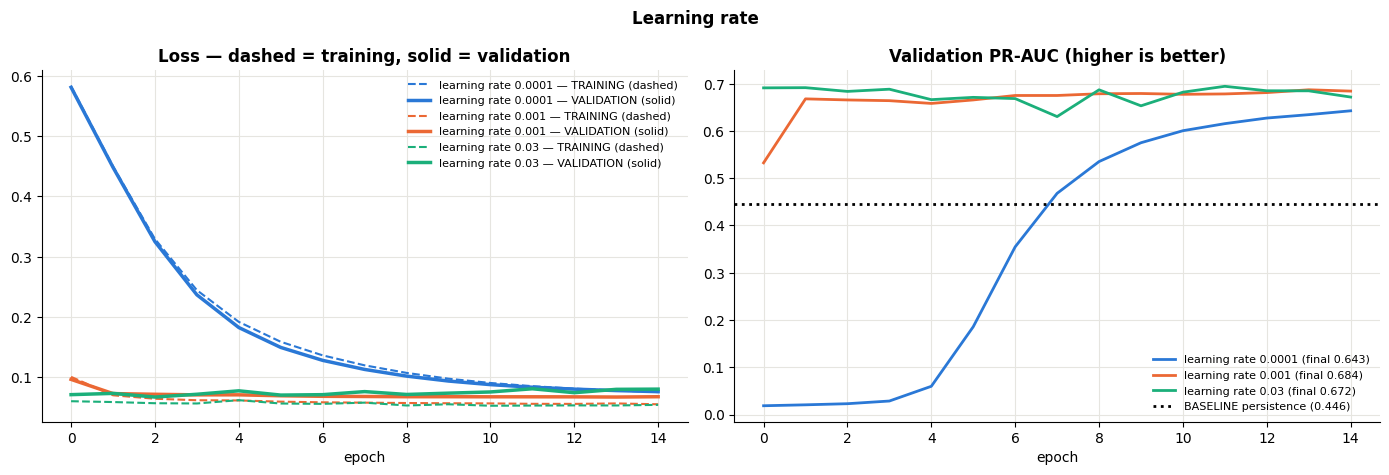

In [25]:
learning_rates = [0.0001, 0.001, 0.03]                                 # three learning rates
lr_results = []                                                        # empty list for the results
for lr in learning_rates:                                              # for each learning rate...
    result = train_model(learning_rate=lr)                             # ...train a model...
    lr_results.append(result)                                          # ...and keep its results
plot_curves(lr_results, ["learning rate 0.0001", "learning rate 0.001", "learning rate 0.03"], "Learning rate")  # draw

📖 **Reading:** a very small learning rate learns slowly; a large one is fast but jumpy. The middle value is a good compromise.

### 🧑‍💻 Optional coding challenge B — the batch size
*Optional, for those who want to write code.*

**Task:** train three models with `batch_size` = 32, 256 and 4096 and draw their curves with `plot_curves`, following the pattern of §7.3.
What happens with very large batches, and why? **Variation:** try the largest batch again with `learning_rate=0.01`.

Solution: `solutions/Lab2_low_visibility_SOLUTIONS.ipynb`

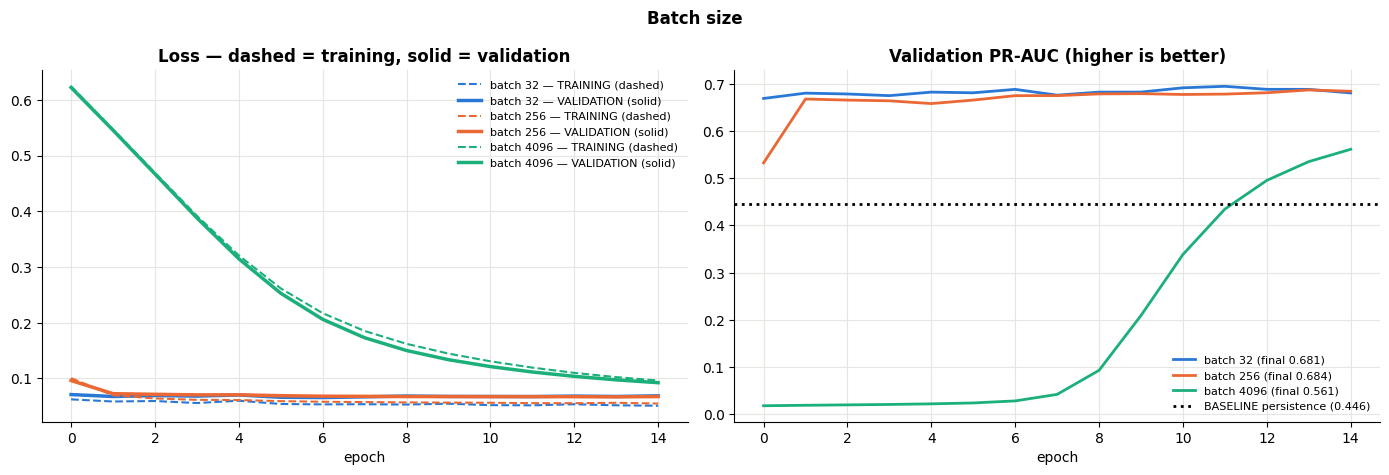

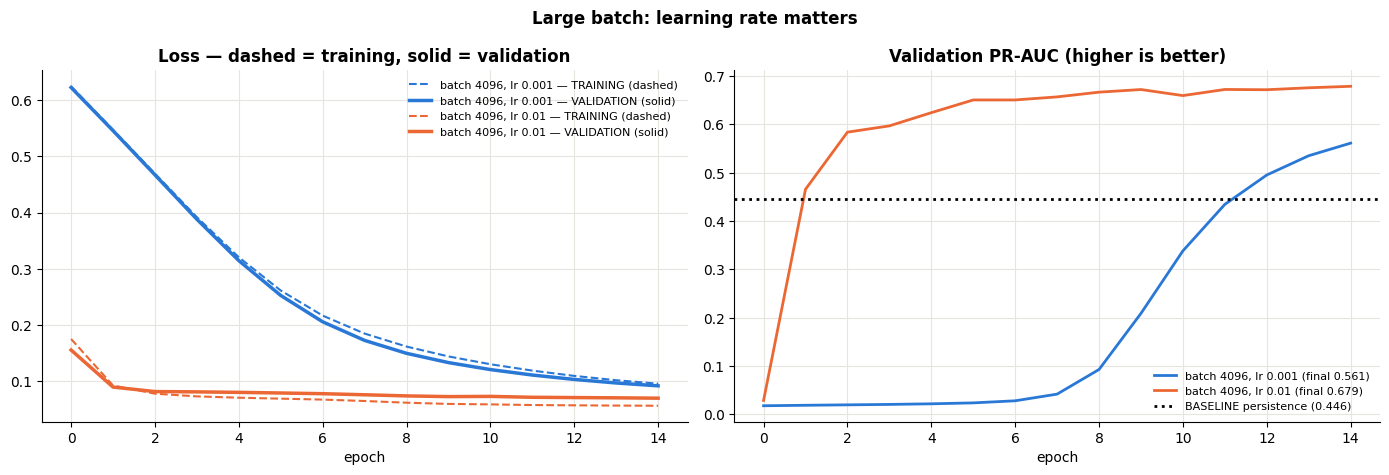

In [26]:
# 🧑‍💻 OPTIONAL CHALLENGE B — SOLUTION
batch_sizes = [32, 256, 4096]                                # three batch sizes
batch_results = []                                           # empty list for the results
for batch_size in batch_sizes:                               # for each batch size...
    result = train_model(batch_size=batch_size)              # ...train a model...
    batch_results.append(result)                             # ...and keep its results
plot_curves(batch_results, ["batch 32", "batch 256", "batch 4096"], "Batch size")   # draw the three runs

# Variation: the largest batch with a larger learning rate
big_batch_fast = train_model(batch_size=4096, learning_rate=0.01)   # 4096 examples per batch, bigger steps
plot_curves([batch_results[2], big_batch_fast], ["batch 4096, lr 0.001", "batch 4096, lr 0.01"], "Large batch: learning rate matters")
# Reading: with 4096 examples per batch there are only ~9 corrections per epoch, so in 15 epochs the model barely learns.
# A larger learning rate compensates: batch size and learning rate are not independent.

### 7.4 All experiments in one table

In [27]:
my_run = train_model(hidden=32, dropout=0.1, learning_rate=0.001, epochs=20, pos_weight=3.0)   # one more run (you can change it)

all_results = [first_run]                                              # a list with every run...
all_results.extend(weight_results)                                     # ...the class-weight runs
all_results.extend(size_results)                                       # ...the size/dropout runs
all_results.extend(lr_results)                                         # ...the learning-rate runs
all_results.append(my_run)                                             # ...and the extra run

rows = []                                                              # one table row per run
for result in all_results:                                             # for each run...
    row = dict(result["settings"])                                     # ...its settings...
    row["validation PR-AUC"] = round(result["validation_scores"]["PR-AUC"], 3)   # ...its PR-AUC...
    row["seconds"] = round(result["seconds"], 1)                       # ...and its training time
    rows.append(row)                                                   # add the row
leaderboard = pd.DataFrame(rows)                                       # turn the rows into a table
settings_columns = ["hidden", "dropout", "learning_rate", "epochs", "batch_size", "pos_weight"]   # the settings columns
leaderboard = leaderboard.drop_duplicates(subset=settings_columns)    # remove runs with identical settings (same result)
leaderboard = leaderboard.sort_values("validation PR-AUC", ascending=False)   # sort: best first
leaderboard                                                            # display

,hidden,dropout,learning_rate,epochs,batch_size,pos_weight,validation PR-AUC,seconds
10,32,0.1,0.0010,20,256,3.0,0.691,6.3
2,32,0.0,0.0010,15,256,10.0,0.689,3.8
0,32,0.0,0.0010,15,256,1.0,0.684,3.4
4,16,0.0,0.0010,40,256,1.0,0.683,10.7
6,256,0.3,0.0010,40,256,1.0,0.679,26.1
9,32,0.0,0.0300,15,256,1.0,0.672,3.6
3,32,0.0,0.0010,15,256,30.0,0.670,4.1
5,256,0.0,0.0010,40,256,1.0,0.657,18.7
7,32,0.0,0.0001,15,256,1.0,0.643,3.6


---
## 8 · Choosing the alert threshold
The model gives a probability; operations need a **yes/no alert**. We choose the threshold on the **validation** year, from a user requirement.
A plausible one: *"catch at least 80 % of the low-visibility cases"* (recall ≥ 0.80).

Selected settings: {'hidden': 32, 'dropout': 0.1, 'learning_rate': 0.001, 'epochs': 20, 'batch_size': 256, 'pos_weight': 3.0}


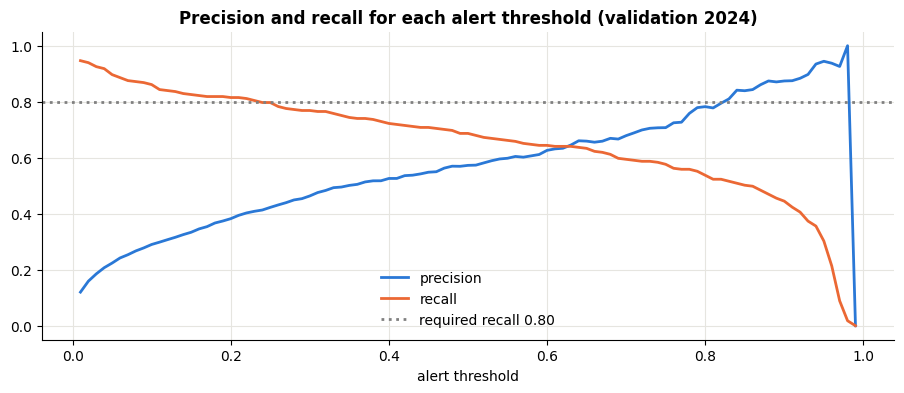

Chosen threshold: 0.23


In [28]:
best = all_results[0]                                                  # assume the first run is the best...
for result in all_results:                                             # ...then look at every run:
    if result["validation_scores"]["PR-AUC"] > best["validation_scores"]["PR-AUC"]:   # if it has a higher PR-AUC...
        best = result                                                  # ...it becomes the best
print("Selected settings:", best["settings"])                          # show them

truth_validation = y_all[is_validation]                                # true answers on validation hours
probabilities = best["validation_probabilities"]                       # the best model's probabilities

candidate_thresholds = np.arange(0.01, 1.0, 0.01)                      # thresholds 0.01, 0.02, ..., 0.99
precisions = []                                                        # precision at each threshold
recalls = []                                                           # recall at each threshold
for threshold in candidate_thresholds:                                 # for each threshold...
    alerts = (probabilities >= threshold).astype(float)                # ...alerts = probability above the threshold
    precisions.append(precision_score(truth_validation, alerts, zero_division=0))   # ...its precision
    recalls.append(recall_score(truth_validation, alerts))             # ...its recall

plt.figure(figsize=(11, 4))                                            # new figure
plt.plot(candidate_thresholds, precisions, label="precision")          # precision curve
plt.plot(candidate_thresholds, recalls, label="recall")                # recall curve
plt.axhline(0.80, color="grey", linestyle=":", label="required recall 0.80")   # the requirement
plt.xlabel("alert threshold")                                          # horizontal axis label
plt.title("Precision and recall for each alert threshold (validation 2024)")   # title
plt.legend()                                                           # legend
plt.show()                                                             # display

THRESHOLD = 0.01                                                       # start from the lowest threshold...
for i in range(len(candidate_thresholds)):                             # ...and go through all thresholds:
    if recalls[i] >= 0.80:                                             # while the requirement is still met...
        THRESHOLD = candidate_thresholds[i]                            # ...remember this (higher) threshold
print("Chosen threshold:", round(THRESHOLD, 2))                        # the highest threshold that keeps recall ≥ 0.80

📖 **Reading:** raising the threshold gives fewer, more reliable alerts (precision up) but misses more cases (recall down). We take the **highest threshold that still catches 80 %** of the cases.

---
## 9 · Final test on 2025 (used only once)

In [29]:
test_probabilities = predict_probability(best["model"], X_scaled[is_test])   # probabilities on the test year
test_truth = y_all[is_test]                                            # true answers on the test year
test_alerts = (test_probabilities >= THRESHOLD).astype(float)          # alerts with the chosen threshold

final = pd.DataFrame()                                                 # a comparison table
final["persistence"] = pd.Series(scores(test_truth, persistence_all[is_test]))                # persistence on 2025
final["neural network"] = pd.Series(scores(test_truth, test_alerts, test_probabilities))      # our model on 2025
final.T.round(3)                                                       # display, one row per method

,accuracy,precision,recall,PR-AUC
persistence,0.982,0.741,0.472,0.364
neural network,0.955,0.332,0.775,0.523


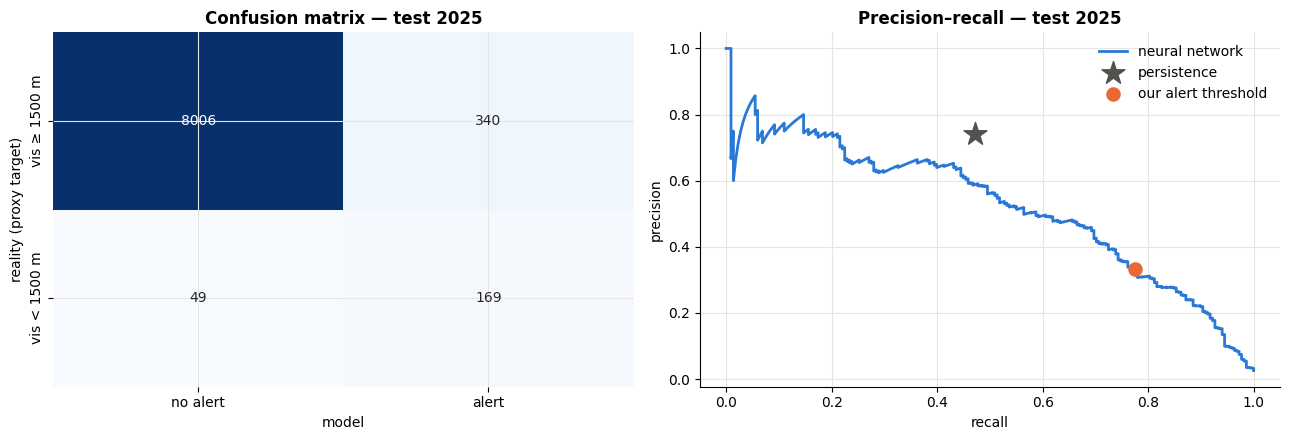

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))                      # two plots side by side

matrix = confusion_matrix(test_truth, test_alerts)                     # counts of right/wrong answers
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["no alert", "alert"], yticklabels=["vis ≥ 1500 m", "vis < 1500 m"])   # draw them as a grid
axes[0].set_title("Confusion matrix — test 2025")                      # left title
axes[0].set_xlabel("model")                                            # left horizontal label
axes[0].set_ylabel("reality (proxy target)")                           # left vertical label

precision, recall, thresholds = precision_recall_curve(test_truth, test_probabilities)   # the model's curve on 2025
axes[1].plot(recall, precision, color=PALETTE[0], label="neural network")                # draw it
p = final["persistence"]                                               # persistence measures on 2025
axes[1].scatter(p["recall"], p["precision"], marker="*", s=300, color="#52514e", label="persistence")   # star
n = final["neural network"]                                            # model measures on 2025
axes[1].scatter(n["recall"], n["precision"], s=90, color=PALETTE[1], label="our alert threshold", zorder=3)   # dot
axes[1].set_xlabel("recall")                                           # right horizontal label
axes[1].set_ylabel("precision")                                        # right vertical label
axes[1].set_title("Precision–recall — test 2025")                      # right title
axes[1].legend()                                                       # right legend

plt.tight_layout()                                                     # adjust spacing
plt.show()                                                             # display

📖 **Reading:** the confusion matrix counts the hours: top-left = correctly quiet, bottom-right = correctly alerted, top-right = false alarms, bottom-left = missed cases.
Our model catches many more cases than persistence (higher recall), at the price of more false alarms.

### 9.1 What the forecast looks like in practice

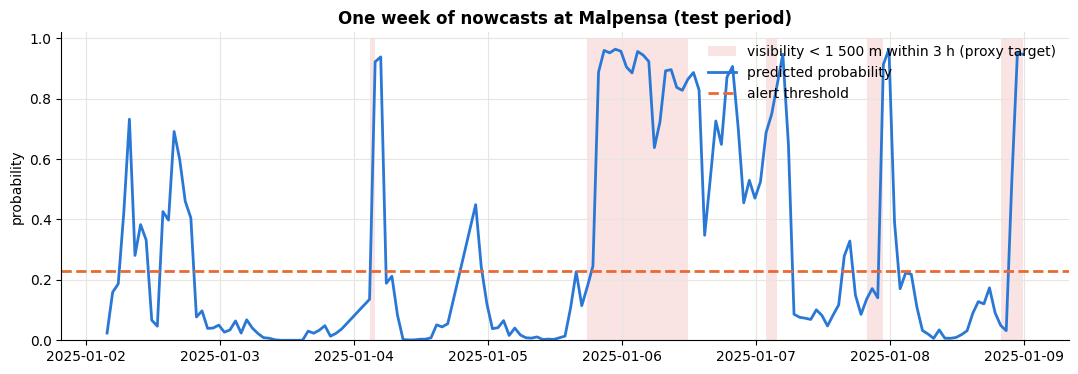

In [31]:
test_table = dataset[is_test].copy()                                   # the test hours...
test_table["probability"] = test_probabilities                         # ...with the model's probability added
week = test_table.loc["2025-01-02":"2025-01-08"]                       # one week in January 2025

plt.figure(figsize=(13, 4))                                            # new figure
is_low = week["target"] == 1                                           # hours where the target is 1
plt.fill_between(week.index, 0, 1, where=is_low, color=PALETTE[7], alpha=0.15, linewidth=0,
                 label="visibility < 1 500 m within 3 h (proxy target)")   # shade those hours in red
plt.plot(week.index, week["probability"], color=PALETTE[0], label="predicted probability")   # the model's probability
plt.axhline(THRESHOLD, color=PALETTE[1], linestyle="--", label="alert threshold")           # the threshold
plt.ylim(0, 1.02)                                                      # vertical axis from 0 to 1
plt.ylabel("probability")                                              # vertical axis label
plt.title("One week of nowcasts at Malpensa (test period)")            # title
plt.legend(loc="upper right")                                          # legend
plt.show()                                                             # display

📖 **Reading:** the probability often rises **before** the shaded periods begin — something persistence can never do — and falls when the fog lifts. You can also spot false alarms (probability above the threshold outside the shaded areas).

### 🧑‍💻 Optional coding challenge C — a different operational requirement
*Optional, for those who want to write code.*

Suppose the airport operator says instead: *"at least half of the alerts must be right"* (precision ≥ 0.5).
**Task:** find the **lowest** threshold that gives precision ≥ 0.5 on validation (use `candidate_thresholds` and `precisions` from §8),
then compute the scores on the 2025 test year. How many low-visibility cases do we now catch?

Solution: `solutions/Lab2_low_visibility_SOLUTIONS.ipynb`

In [32]:
# 🧑‍💻 OPTIONAL CHALLENGE C — SOLUTION
REQUIRED_PRECISION = 0.50                                    # the new requirement
new_threshold = None                                         # not found yet
for i in range(len(candidate_thresholds)):                   # go through the thresholds, from low to high...
    if precisions[i] >= REQUIRED_PRECISION:                  # ...if this one meets the requirement...
        new_threshold = candidate_thresholds[i]              # ...remember it...
        break                                                # ...and stop: it is the lowest one that works
print("New threshold:", round(new_threshold, 2))             # show it

new_alerts = (test_probabilities >= new_threshold).astype(float)   # alerts on 2025 with the new threshold
new_scores = scores(test_truth, new_alerts, test_probabilities)    # the measures on 2025
for name in new_scores:                                      # print each measure...
    print(name, "=", round(new_scores[name], 3))             # ...with its value
# Reading: compared with the 80 %-recall threshold we get fewer false alarms (higher precision) but miss more cases
# (lower recall). Note that on 2025 the precision is below the 0.5 required on 2024: a threshold chosen on past data
# does not guarantee the same performance on new data — requirements must be monitored in operation.

New threshold: 0.35
accuracy = 0.964
precision = 0.392
recall = 0.734
PR-AUC = 0.523


### 9.2 Which inputs does the model rely on?
We shuffle one input at a time (destroying its information) and measure how much the PR-AUC drops. A big drop = an important input.

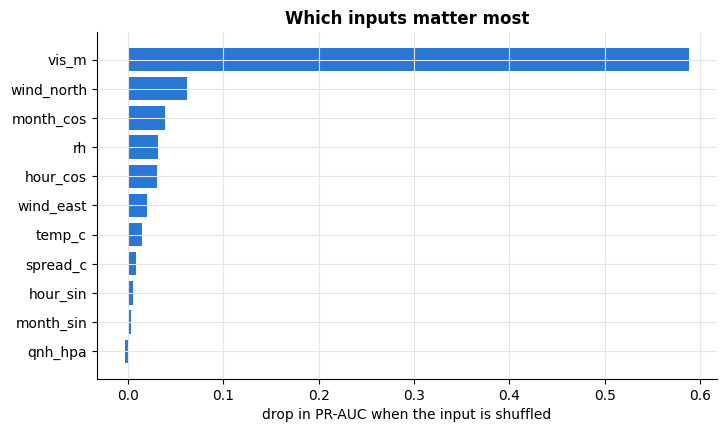

In [33]:
rng = np.random.default_rng(SEED)                                      # a random-number generator with a fixed seed
X_validation = X_scaled[is_validation]                                 # validation inputs
truth_validation = y_all[is_validation]                                # validation answers
base_prauc = average_precision_score(truth_validation, predict_probability(best["model"], X_validation))  # normal PR-AUC

drops = []                                                             # the PR-AUC drop for each input
for j in range(len(FEATURES)):                                         # for each input (column j)...
    shuffled = X_validation.copy()                                     # ...copy the inputs...
    shuffled[:, j] = rng.permutation(shuffled[:, j])                   # ...shuffle column j only...
    new_prauc = average_precision_score(truth_validation, predict_probability(best["model"], shuffled))  # ...re-score
    drops.append(base_prauc - new_prauc)                               # ...and store the drop

importance = pd.Series(drops, index=FEATURES).sort_values()            # put the drops in a sorted series
plt.figure(figsize=(8, 4.5))                                           # new figure
plt.barh(importance.index, importance.values, color=PALETTE[0])        # one horizontal bar per input
plt.xlabel("drop in PR-AUC when the input is shuffled")                # horizontal axis label
plt.title("Which inputs matter most")                                  # title
plt.show()                                                             # display

📖 **Reading:** **current visibility** dominates — persistence is built into the model. Wind, season, humidity and hour follow.
⚠️ The temperature − dew point spread looks unimportant even though it is a key physical signal: it carries the **same information as humidity**, so when one is shuffled
the model still gets it from the other. This method shows what *this model* needs, not what the physics needs.

---
## 10 · Questions for discussion
1. Why is a 97 %-accurate model useless here? Which measure would you report to an airport operator?
2. `pos_weight` and the alert threshold both change the balance between missed cases and false alarms. **Who should decide** that balance?
3. The model relies heavily on current visibility. Would it still beat persistence if we evaluated it only on the start of fog events?
4. Our target is a **proxy** (visibility < 1 500 m), not the real LVP declaration. If the airport gave you its log of LVP start and end times, how could the two differ (RVR vs visibility, cloud ceiling, declaration delays)? Which one would operations want the model to predict?

## 11 · Ideas to explore further (optional)
- In §7.4, change the settings of `my_run` and see if you can beat the leaderboard.
- Change `THRESHOLD` in §8 (for example to 0.5) and re-run §9: how do precision and recall change?
- A more LVP-like target: the raw `metar` text contains the **RVR** for each runway (e.g. `R35L/0300N`) and the file has the **cloud base** (`skyc1`, `skyl1`). They could be used to define a target closer to real LVP.

## ⚠️ Things that often go wrong in ML projects
> - **Using accuracy for rare events** — always look at precision, recall and PR-AUC.
> - **Future leakage** — the target may look into the future; the inputs must not.
> - **Choosing the threshold on the test data** — it is a setting like any other: choose it on validation.